# Titanic Dataset - Data Analysis

**Dataset:** Titanic-Dataset.csv  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

## Introduction

The Titanic dataset contains information about passengers aboard the RMS Titanic, which sank on April 15, 1912. Out of around 2,224 people on board, only about 710 survived.

The goal of this analysis is to explore patterns in the data and understand what factors influenced survival.

Questions I want to answer:
- What was the overall survival rate?
- Did gender play a role in survival?
- Did passenger class affect survival chances?
- How did age relate to survival?
- Did family size on board matter?


## Step 1 - Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


## Step 2 - Load the Dataset

In [34]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3 - Data Overview

In [35]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [36]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [37]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]


,Missing Count,Missing %
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


## Step 4 - Data Preprocessing

Steps taken:
- Remove duplicate rows
- Fill missing Age values with the median
- Fill missing Embarked with the mode
- Drop Cabin column (about 77% of values are missing)
- Drop columns that are not useful for analysis: PassengerId, Name, Ticket
- Fix data types
- Create two new columns: FamilySize and AgeGroup


In [38]:
# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print("Duplicates removed:", before - len(df))

# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin - too many missing values
df.drop(columns=['Cabin'], inplace=True)

# Drop columns not needed for analysis
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Fix data types
df['Survived'] = df['Survived'].astype(int)
df['Pclass']   = df['Pclass'].astype('category')
df['Sex']      = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

# New feature: family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# New feature: age group
bins   = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("Done. Final shape:", df.shape)
print("Missing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Duplicates removed: 0
Done. Final shape: (891, 10)
Missing values remaining:
Age         177
Embarked      2
AgeGroup    177
dtype: int64


In [39]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,2,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,2,Adult
2,1,3,female,26.0,0,0,7.9250,S,1,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,2,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,1,Young Adult
5,0,3,male,NaN,0,0,8.4583,Q,1,NaN
6,0,1,male,54.0,0,0,51.8625,S,1,Adult
7,0,3,male,2.0,3,1,21.0750,S,5,Child
8,1,3,female,27.0,0,2,11.1333,S,3,Young Adult
9,1,2,female,14.0,1,0,30.0708,C,2,Teen


## Step 5 - Analysis

In [40]:
total     = len(df)
survived  = df['Survived'].sum()
not_surv  = total - survived

print("Total passengers :", total)
print("Survived         :", survived, f"({round(survived/total*100, 1)}%)")
print("Did not survive  :", not_surv, f"({round(not_surv/total*100, 1)}%)")

print("\nAverage age (overall)        :", round(df['Age'].mean(), 1))
print("Average age (survived)       :", round(df[df['Survived']==1]['Age'].mean(), 1))
print("Average age (not survived)   :", round(df[df['Survived']==0]['Age'].mean(), 1))

print("\nAverage fare (overall)       :", round(df['Fare'].mean(), 2))
print("Average fare (survived)      :", round(df[df['Survived']==1]['Fare'].mean(), 2))
print("Average fare (not survived)  :", round(df[df['Survived']==0]['Fare'].mean(), 2))


Total passengers : 891
Survived         : 342 (38.4%)
Did not survive  : 549 (61.6%)

Average age (overall)        : 29.7
Average age (survived)       : 28.3
Average age (not survived)   : 30.6

Average fare (overall)       : 32.2
Average fare (survived)      : 48.4
Average fare (not survived)  : 22.12


In [41]:
print("Survival rate by gender:")
print(df.groupby('Sex')['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))

print("\nSurvival rate by class:")
print(df.groupby('Pclass', observed=True)['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))

print("\nSurvival rate by age group:")
print(df.groupby('AgeGroup', observed=True)['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))

print("\nSurvival rate by family size:")
print(df.groupby('FamilySize')['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))


Survival rate by gender:
Sex
female    74.2%
male      18.9%
Name: Survived, dtype: str

Survival rate by class:
Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: str

Survival rate by age group:
AgeGroup
Child          58.0%
Teen           42.9%
Young Adult    38.3%
Adult          40.0%
Senior         22.7%
Name: Survived, dtype: str

Survival rate by family size:
FamilySize
1     30.4%
2     55.3%
3     57.8%
4     72.4%
5     20.0%
6     13.6%
7     33.3%
8      0.0%
11     0.0%
Name: Survived, dtype: str


## Step 6 - Visualizations

### Overall Survival

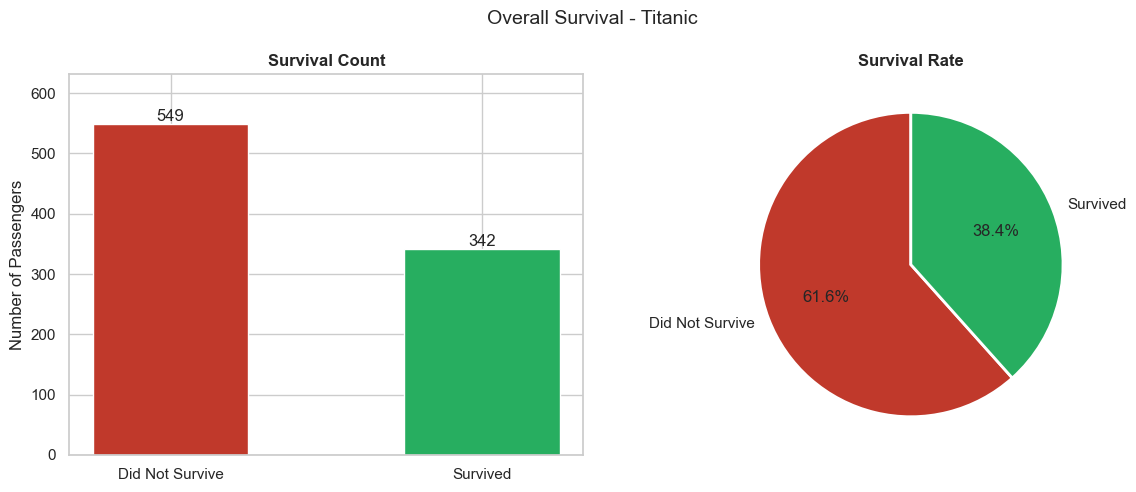

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Survived'].value_counts().sort_index()
bar_labels = ['Did Not Survive', 'Survived']
bar_colors = ['#c0392b', '#27ae60']

bars = axes[0].bar(bar_labels, counts.values, color=bar_colors, width=0.5)
axes[0].set_title('Survival Count')
axes[0].set_ylabel('Number of Passengers')
axes[0].set_ylim(0, max(counts.values) * 1.15)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5, str(val), ha='center', fontsize=12)

axes[1].pie(counts.values, labels=bar_labels, autopct='%1.1f%%',
            colors=bar_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Survival Rate')

plt.suptitle('Overall Survival - Titanic', fontsize=14)
plt.tight_layout()
plt.show()


### Survival by Gender

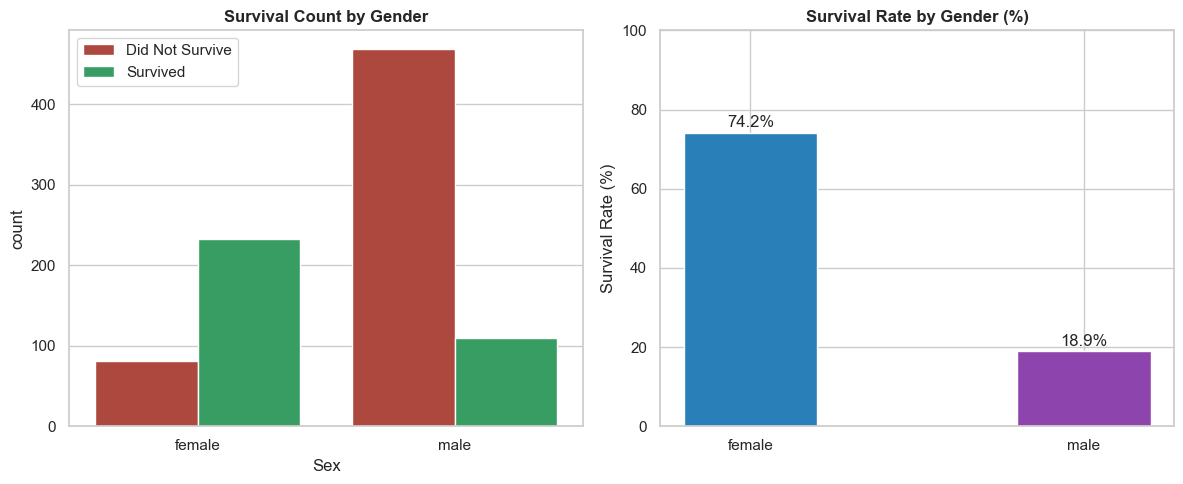

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Sex', hue='Survived',
              palette={0: '#c0392b', 1: '#27ae60'}, ax=axes[0])
axes[0].set_title('Survival Count by Gender')
axes[0].legend(['Did Not Survive', 'Survived'])

surv_sex = df.groupby('Sex', observed=True)['Survived'].mean() * 100
bars = axes[1].bar(surv_sex.index, surv_sex.values,
                   color=['#2980b9', '#8e44ad'], width=0.4)
axes[1].set_title('Survival Rate by Gender (%)')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, surv_sex.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f"{val:.1f}%", ha='center', fontsize=12)

plt.tight_layout()
plt.show()


### Survival by Passenger Class

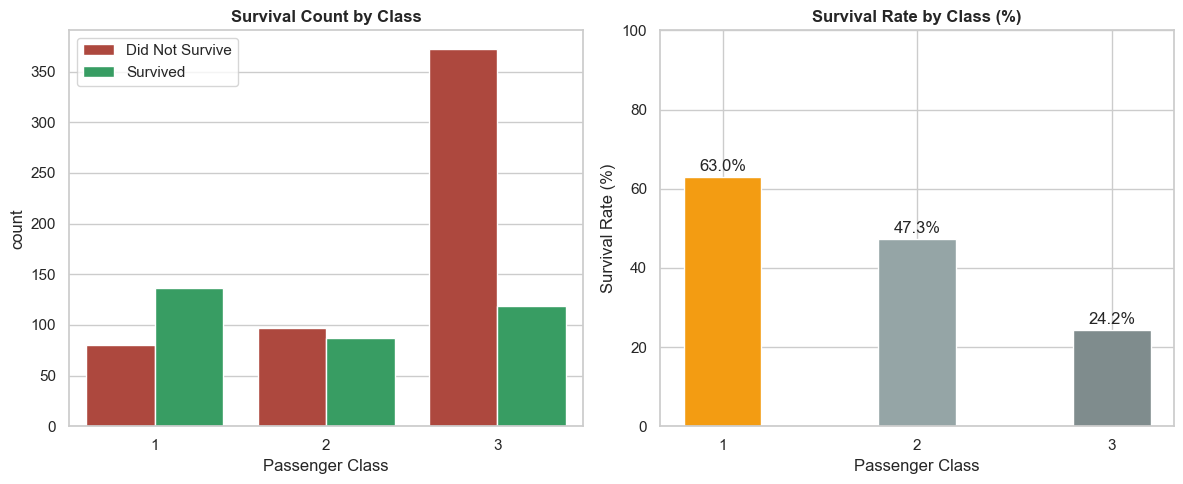

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Pclass', hue='Survived',
              palette={0: '#c0392b', 1: '#27ae60'}, ax=axes[0])
axes[0].set_title('Survival Count by Class')
axes[0].set_xlabel('Passenger Class')
axes[0].legend(['Did Not Survive', 'Survived'])

surv_cls = df.groupby('Pclass', observed=True)['Survived'].mean() * 100
bars = axes[1].bar([str(c) for c in surv_cls.index], surv_cls.values,
                   color=['#f39c12', '#95a5a6', '#7f8c8d'], width=0.4)
axes[1].set_title('Survival Rate by Class (%)')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, surv_cls.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f"{val:.1f}%", ha='center', fontsize=12)

plt.tight_layout()
plt.show()


### Age Distribution

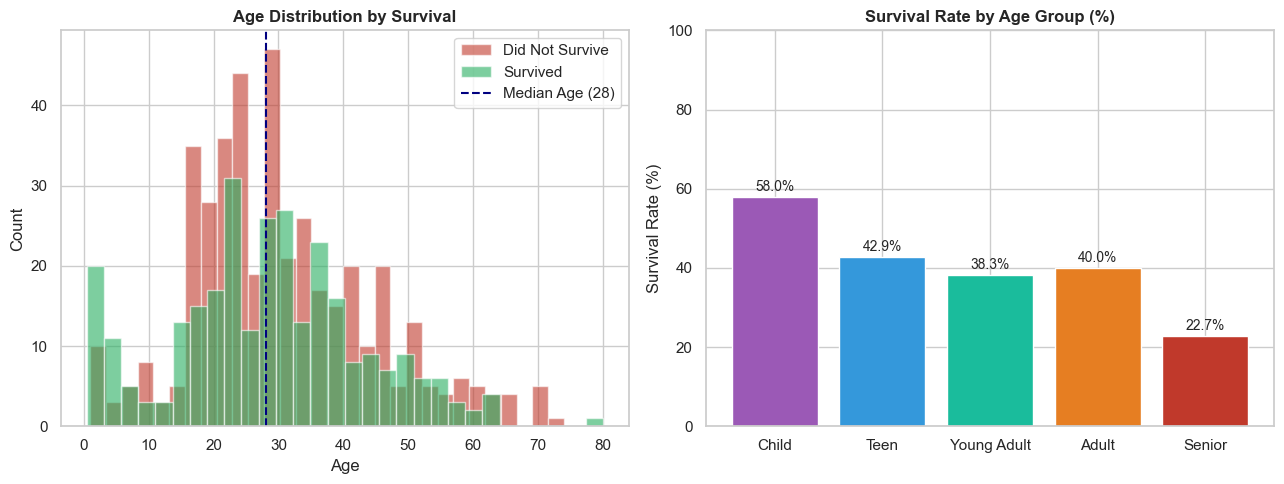

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df[df['Survived']==0]['Age'], bins=30, alpha=0.6,
             color='#c0392b', label='Did Not Survive')
axes[0].hist(df[df['Survived']==1]['Age'], bins=30, alpha=0.6,
             color='#27ae60', label='Survived')
axes[0].axvline(df['Age'].median(), color='navy', linestyle='--',
                linewidth=1.5, label=f"Median Age ({df['Age'].median():.0f})")
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

surv_age = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
clrs = ['#9b59b6', '#3498db', '#1abc9c', '#e67e22', '#c0392b']
bars = axes[1].bar(surv_age.index, surv_age.values, color=clrs)
axes[1].set_title('Survival Rate by Age Group (%)')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, surv_age.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f"{val:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### Fare vs Age

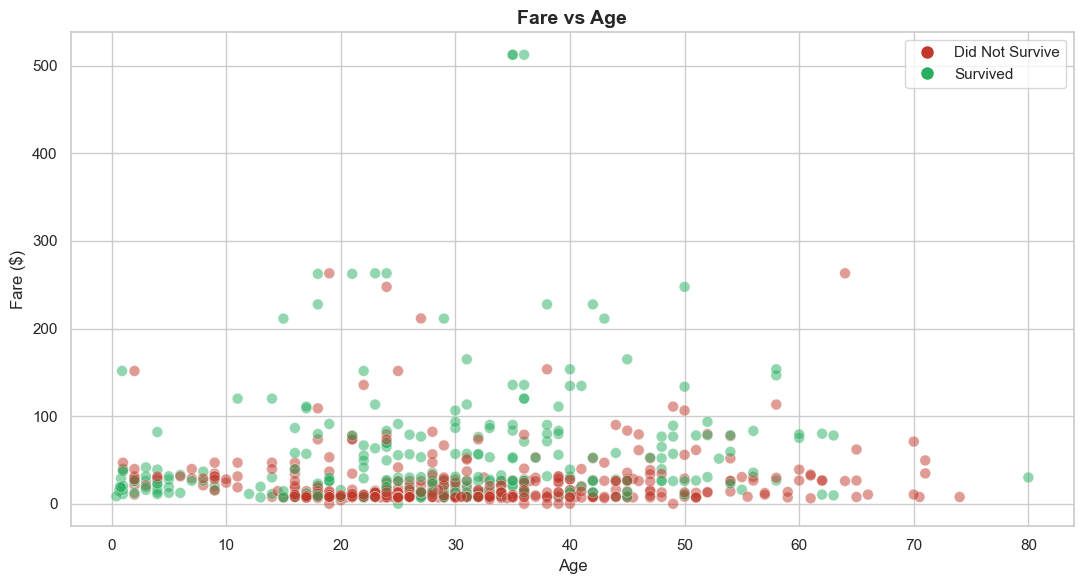

In [46]:
from matplotlib.lines import Line2D

plt.figure(figsize=(11, 6))
colors = df['Survived'].map({0: '#c0392b', 1: '#27ae60'})
plt.scatter(df['Age'], df['Fare'], c=colors, alpha=0.5,
            edgecolors='white', linewidth=0.4, s=60)

handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#c0392b',
           markersize=10, label='Did Not Survive'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#27ae60',
           markersize=10, label='Survived')
]
plt.legend(handles=handles, fontsize=11)
plt.title('Fare vs Age', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.show()


### Survival by Family Size

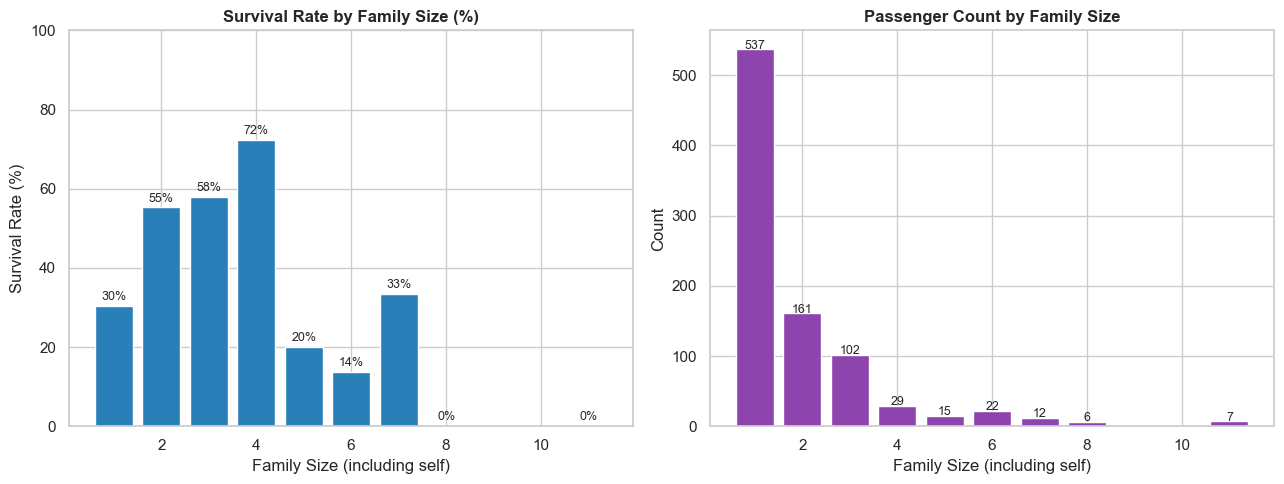

In [47]:
surv_fam  = df.groupby('FamilySize')['Survived'].mean() * 100
count_fam = df['FamilySize'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(surv_fam.index, surv_fam.values, color='#2980b9')
axes[0].set_title('Survival Rate by Family Size (%)')
axes[0].set_xlabel('Family Size (including self)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for i, val in zip(surv_fam.index, surv_fam.values):
    axes[0].text(i, val + 1.5, f"{val:.0f}%", ha='center', fontsize=9)

axes[1].bar(count_fam.index, count_fam.values, color='#8e44ad')
axes[1].set_title('Passenger Count by Family Size')
axes[1].set_xlabel('Family Size (including self)')
axes[1].set_ylabel('Count')
for i, val in zip(count_fam.index, count_fam.values):
    axes[1].text(i, val + 1, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### Correlation Heatmap

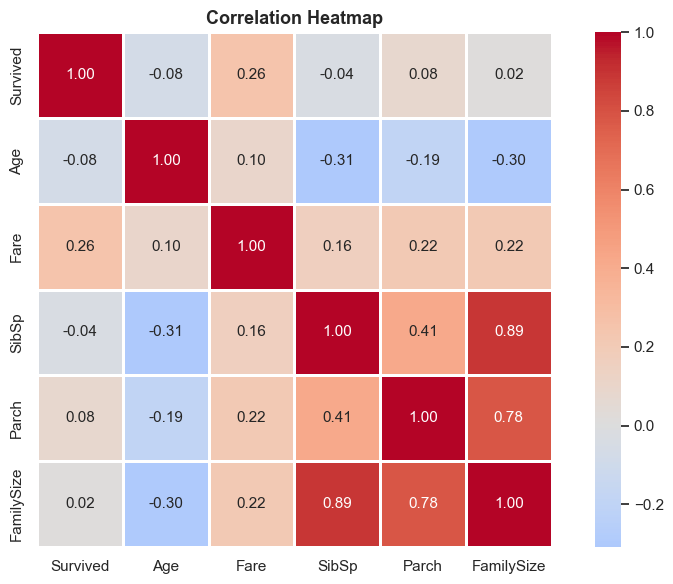

In [48]:
plt.figure(figsize=(9, 6))
cols = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
corr = df[cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1,
            annot_kws={'size': 11})
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()


## Step 7 - Conclusion

**Overall survival rate:** Only 38.4% of passengers survived.

**Gender:** Female passengers survived at a rate of about 74%, while only around 19% of males survived. This is likely because of the "women and children first" rule followed during the evacuation.

**Passenger class:** 1st class passengers had a survival rate of around 63%, compared to just 24% for 3rd class. Better cabin locations and priority access to lifeboats likely played a role here.

**Age:** Children had the highest survival rate among all age groups. Seniors had the lowest.

**Fare:** Survivors paid higher fares on average ($48 vs $22), which ties back to class — wealthier passengers bought better tickets and had better chances.

**Family size:** Passengers traveling alone or in very large groups had lower survival rates. Small families of 2 to 4 people did the best.

Overall, survival on the Titanic was heavily influenced by social class, gender, and age. It was not random — those with money, or who were female or young, had a significantly better chance of making it out.
